# **KNN Imputer**

### Univariate vs. Multivariate Imputation

**Univariate Imputation**

Univariate imputation involves imputing missing values in a single feature (column) using only the available information from that same feature. Common methods include:
- **Mean imputation**: Replacing missing values with the mean of the observed values in the column.
- **Median imputation**: Replacing missing values with the median of the observed values in the column.
- **Mode imputation**: Replacing missing values with the mode (most frequent value) of the observed values in the column.
- **Constant imputation**: Replacing missing values with a specified constant value.

*Pros/Cons*: Simple to implement but can lead to biased estimates and may underestimate the variance of the imputed variable, as it ignores relationships with other variables.

**Multivariate Imputation**

Multivariate imputation involves estimating missing values in a feature by taking into account the relationships with other features in the dataset. These methods leverage the correlation structure between variables to provide more accurate imputations. Common methods include:
- **K-Nearest Neighbors (KNN) imputation**: Missing values are imputed based on the values of the k-nearest neighbors in the feature space. The "distance" to find neighbors considers all available features.
- **Multiple Imputation by Chained Equations (MICE)**: An iterative process where each incomplete feature is imputed using a prediction model (e.g., linear regression) based on other features.
- **PCA based imputation**: Using principal components to estimate missing values.

*Pros/Cons*: Generally more sophisticated and can provide more accurate imputations, preserving relationships between variables better than univariate methods. However, they are more computationally intensive.

# K-Nearest Neighbors (KNN) Algorithm

The KNN Imputer is a multivariate imputation method that fills in missing values by considering the values of the nearest neighbors of the data point with missing values. Unlike univariate methods, which consider only one variable at a time, the KNN Imputer uses multiple variables, making it a more robust and reliable approach for estimating missing data.

K-Nearest Neighbors (KNN) is a simple, non-parametric, lazy learning algorithm primarily used for classification and regression tasks. It's considered "lazy" because it does not construct a model during the training phase; instead, it memorizes the entire training dataset. All computations are deferred until a prediction is requested.

## How KNN Works

The core principle of KNN is that data points that are similar tend to exist in close proximity within the feature space. When a new, unseen data point requires classification or a value prediction, KNN identifies its 'k' nearest neighbors from the training dataset.


- **Distance Calculation**: For each missing value, the KNN Imputer calculates the distance between the data point with missing values and all other data points in the dataset. The default distance metric used is the Euclidean distance, which is NaN-aware, meaning it can handle missing values without biasing the distance calculation. 
- **Identifying Neighbors**: The algorithm identifies the ‘k’ nearest neighbors to the data point with the missing value. These neighbors are the data points with the smallest distance to the point with the missing value. 
- **Imputation**: The missing value is imputed using the mean (or median) of the identified nearest neighbors. This approach ensures that the imputed value is influenced by the most similar data points, thereby maintaining the integrity of the dataset. 
- **Handling Multivariate Data**: In multivariate datasets, the KNN Imputer considers all available features, making it more effective in capturing the underlying patterns and relationships between variables.



### For Classification Tasks:

1.  **Choose the Value of K:** Select the number of nearest neighbors (`K`) to consider. `K` is typically a small, odd integer (e.g., 3, 5, 7) to prevent ties when determining the majority class.
2.  **Calculate Distances:** For the new data point, compute its distance to *every* data point in the training dataset. Common distance metrics include:
    *   **Euclidean Distance:** The straight-line distance between two points in Euclidean space. For two points $P_1 = (x_1, y_1)$ and $P_2 = (x_2, y_2)$, it's $\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$. For $n$-dimensional space, it's $\sqrt{\sum_{i=1}^{n}(p_{1i} - p_{2i})^2}$. It's the most widely used metric.
    *   **Manhattan Distance (L1 Norm):** The sum of the absolute differences of their Cartesian coordinates. For two points, it's $|x_2-x_1| + |y_2-y_1|$. For $n$-dimensional space, it's $\sum_{i=1}^{n}|p_{1i} - p_{2i}|$. It represents distance travelled along axes at right angles.
    *   **Minkowski Distance:** A generalization of Euclidean and Manhattan distances. It is defined as $(\sum_{i=1}^{n}(|p_{1i} - p_{2i}|)^p)^{1/p}$. When $p=1$, it's Manhattan distance; when $p=2$, it's Euclidean distance.
3.  **Identify K-Nearest Neighbors:** Sort the calculated distances in ascending order and select the `K` data points with the smallest distances. These are the K-nearest neighbors.
4.  **Vote for Class Label:** Examine the class labels of these `K` neighbors. The new data point is assigned the class label that is most frequent among its `K` nearest neighbors (majority vote). In cases of ties with an even `K`, various strategies can be employed, such as taking the next nearest neighbor or assigning randomly.

### For Regression Tasks:

1.  **Choose the Value of K:** Similar to classification, select an appropriate `K`.
2.  **Calculate Distances:** Compute the distance from the new data point to all training data points using a chosen distance metric (e.g., Euclidean).
3.  **Identify K-Nearest Neighbors:** Select the `K` training data points closest to the new point.
4.  **Calculate Average/Weighted Average:** The predicted value for the new data point is typically the average (mean) of the target values of its `K` nearest neighbors. A weighted average can also be used, where closer neighbors contribute more to the average.


# **How Minkowski Distance works**

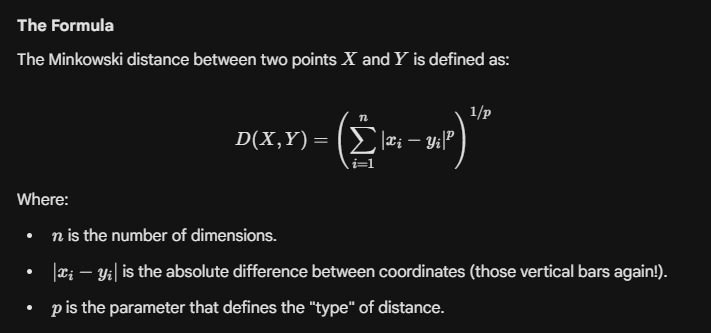

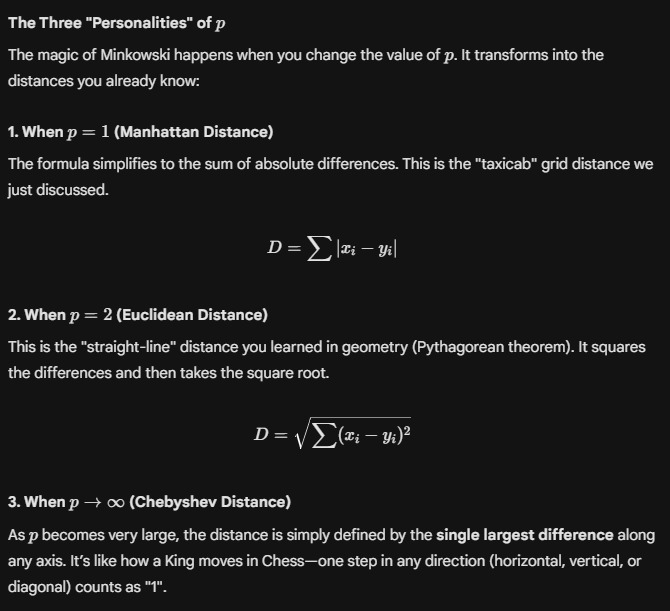

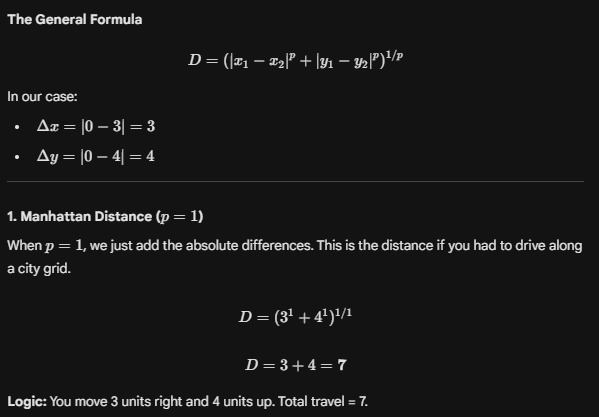

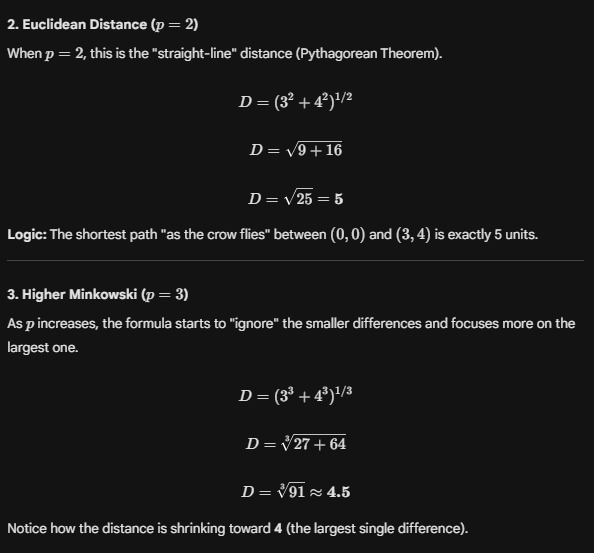

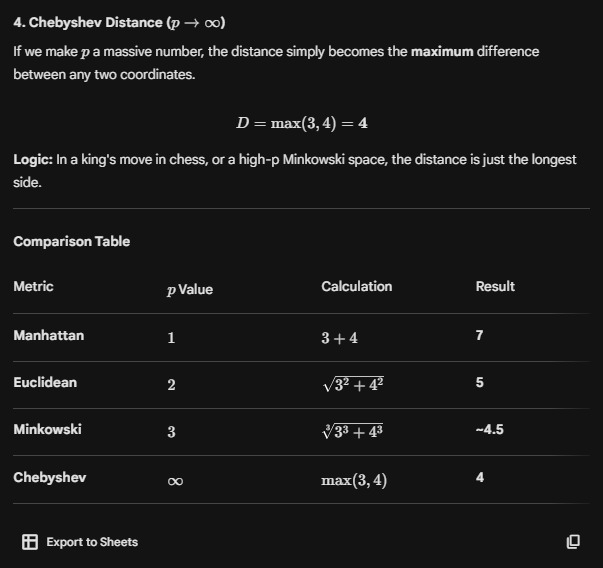


- 1 -- You are traveling on a grid (like city streets). You cannot go diagonally; you must go "over and up."
- 2 -- This is the shortest physical path between two points in a flat plane.
- 3 -- As $p$ increases, the formula becomes more sensitive to large differences in a single dimension. A large gap in one feature is penalized much more heavily than many small gaps across all features.
- infinite -- Only the single largest difference matters. If you are 10 units away in $X$ and 1 unit away in $Y$, the distance is 10. The 1 is ignored.



## Key Considerations and Characteristics:

*   **Non-parametric:** KNN makes no assumptions about the underlying data distribution.
*   **Lazy Learning:** No explicit training phase. All calculations occur during prediction, making it computationally expensive for large datasets during inference.
*   **Feature Scaling:** KNN is sensitive to the scale of features because distance calculations are heavily influenced by features with larger ranges. It's crucial to scale (e.g., standardization or normalization) the features before applying KNN.
*   **Choice of K:**
    *   **Small K:** Can be noisy and sensitive to outliers, potentially leading to overfitting.
    *   **Large K:** Smoothes out predictions, but may blur boundaries between classes or miss fine-grained patterns, potentially leading to underfitting.
    *   The optimal `K` is often found through cross-validation.
*   **Distance Metric:** The choice of distance metric depends on the nature of the data. Euclidean is common for continuous numerical data.
*   **Curse of Dimensionality:** In high-dimensional spaces, the concept of "nearest" becomes less meaningful, as all points tend to be equidistant from each other. This can degrade KNN's performance.
*   **Computational Cost:**
    *   **Training:** O(1) (just storing data).
    *   **Prediction:** O(N * D) where N is the number of training samples and D is the number of features, as it needs to calculate distance to all training points. For very large datasets, this can be slow.
*   **Handling Imbalanced Data:** If one class is dominant, its instances might frequently be among the nearest neighbors, leading to biased predictions. Techniques like weighted voting or over/under-sampling can help.

## Advantages:

*   Simple to understand and implement.
*   No training phase (lazy learner).
*   Can be used for both classification and regression.
*   Effective for non-linear decision boundaries.

## Disadvantages:

*   Computationally expensive during prediction for large datasets.
*   Sensitive to irrelevant or redundant features.
*   Sensitive to the scale of features.
*   Performance degrades with high-dimensional data (curse of dimensionality).
*   Requires sufficient memory to store the entire training dataset.

## Implementation Example (Conceptual Python using scikit-learn):

```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load sample data
iris = load_iris()
X, y = iris.data, iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5) # K=5
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate (e.g., accuracy)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy:.2f}")
```


---
---
---

# KNN Imputer Example to find the missing value 
Now, let's see how KNN fills in a **Missing Value** (`NaN`).
### 1. The Dataset (with a Missing Value)
We have the same car data, but **Car 5** is missing its **Horsepower**.


| ID | Horsepower (X1) | Weight (X2) | Seats (X3) | Top Speed (X4) | Price (X5) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Car 1** | 300 | 1500 | 2 | 250 | 50 |
| **Car 2** | 400 | 1600 | 2 | 280 | 80 |
| **Car 3** | 120 | 2000 | 5 | 160 | 20 |
| **Car 4** | 140 | 2200 | 5 | 170 | 25 |
| **Car 5** | **??? (NaN)** | **1550** | **2** | **260** | **60** |
| **Car 6** | 110 | 1900 | 5 | 150 | 18 |
| **Car 7** | 130 | 2100 | 5 | 165 | 22 |
| **Car 8** | 320 | 1520 | 2 | 255 | 55 |


**Goal:** Find the missing Horsepower for Car 5.
---
### 2. Step 1: Choose K
Let's choose **K = 3**.
---
### 3. Step 2: Calculate Distances
We calculate the distance between **Car 5** and everyone else.
*Note: Since Horsepower is missing, scikit-learn's `KNNImputer` uses a special "nan-euclidean" distance that ignores the missing column and scales up the remaining distance.*
**Simplified Logic:** We compare Car 5 to others using only the **4 available features** (Weight, Seats, Speed, Price).
**Distance to Car 1 [1500, 2, 250, 50]:**
$$ \sqrt{(1550-1500)^2 + (2-2)^2 + (260-250)^2 + (60-50)^2} $$
$$ \sqrt{50^2 + 0 + 10^2 + 10^2} = \sqrt{2500 + 100 + 100} = \sqrt{2700} = \mathbf{51.9} $$
**Distance to Car 8 [1520, 2, 255, 55]:**
$$ \sqrt{(1550-1520)^2 + (2-2)^2 + (260-255)^2 + (60-55)^2} $$
$$ \sqrt{30^2 + 0 + 5^2 + 5^2} = \sqrt{900 + 25 + 25} = \sqrt{950} = \mathbf{30.8} $$
**Distance to Car 3 (Family Car) [2000, 5, 160, 20]:**
$$ \sqrt{(1550-2000)^2 + ...} $$
$$ \sqrt{(-450)^2 + ...} = \mathbf{450+} \text{ (Very Far)} $$


To find the distance, you always subtract the Target Row (the one with the missing value) from Every Other Row in the dataset.

If Car 5 is the one with the missing value:

- Distance 1: (Car 5's numbers) - (Car 1's numbers)
- Distance 2: (Car 5's numbers) - (Car 2's numbers)
- Distance 3: (Car 5's numbers) - (Car 3's numbers)
- ... and so on for every single row.
You are basically measuring: "How different is Car 5 from Car 1? How different is it from Car 2?"


---
### 4. Step 3: Find Nearest Neighbors
The 3 closest cars to Car 5 (based on Weight, Seats, Speed, Price) are:
1.  **Car 8** (Dist: 30.8) -> Horsepower: **320**
2.  **Car 1** (Dist: 51.9) -> Horsepower: **300**
3.  **Car 2** (Dist: ~60.0) -> Horsepower: **400**
---
### 5. Step 4: Calculate Average
We take the **average** of the Horsepower from these 3 neighbors:
$$ \frac{320 + 300 + 400}{3} = \frac{1020}{3} = \mathbf{340} $$

If you dont want the mean value to fill the data, then you can also use median, mode, or any other value.

**Result:**
We fill the missing value with **340**.

| ID | Horsepower | Weight | ... |
| :--- | :--- | :--- | :--- |
| **Car 5** | **340 (Imputed)** | 1550 | ... |

---
---
---


# KNN Calculation Example to make predictioin (5 Features, 8 Rows)
Let's look at a more complex dataset for **Car Classification**.
We want to predict if a car is a **"Sports Car"** or a **"Family Car"**.
### 1. The Dataset (8 Rows, 5 Features)
| ID | Horsepower (X1) | Weight (X2) | Seats (X3) | Top Speed (X4) | Price (X5) | Class (Y) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Car 1** | 300 | 1500 | 2 | 250 | 50 | Sports |
| **Car 2** | 400 | 1600 | 2 | 280 | 80 | Sports |
| **Car 3** | 120 | 2000 | 5 | 160 | 20 | Family |
| **Car 4** | 140 | 2200 | 5 | 170 | 25 | Family |
| **Car 5** | 350 | 1550 | 2 | 260 | 60 | Sports |
| **Car 6** | 110 | 1900 | 5 | 150 | 18 | Family |
| **Car 7** | 130 | 2100 | 5 | 165 | 22 | Family |
| **Car 8** | 320 | 1520 | 2 | 255 | 55 | Sports |
### 2. The New Data Point (Query)
We see a new mystery car:
*   **Mystery Car:** `[310, 1510, 2, 252, 52]`
---
### 3. Step 1: Choose K
Let's choose **K = 3**.
---
### 4. Step 2: Calculate Distances
The formula is the same, just with 5 numbers instead of 2:
$$ \sqrt{(x_1-q_1)^2 + (x_2-q_2)^2 + (x_3-q_3)^2 + (x_4-q_4)^2 + (x_5-q_5)^2} $$
**Distance to Car 1 [300, 1500, 2, 250, 50]:**
$$ \sqrt{(300-310)^2 + (1500-1510)^2 + (2-2)^2 + (250-252)^2 + (50-52)^2} $$
$$ \sqrt{(-10)^2 + (-10)^2 + 0^2 + (-2)^2 + (-2)^2} $$
$$ \sqrt{100 + 100 + 0 + 4 + 4} = \sqrt{208} = \mathbf{14.4} $$
**Distance to Car 8 [320, 1520, 2, 255, 55]:**
$$ \sqrt{(320-310)^2 + (1520-1510)^2 + (2-2)^2 + (255-252)^2 + (55-52)^2} $$
$$ \sqrt{10^2 + 10^2 + 0 + 3^2 + 3^2} $$
$$ \sqrt{100 + 100 + 0 + 9 + 9} = \sqrt{218} = \mathbf{14.7} $$
**Distance to Car 3 (Family) [120, 2000, 5, 160, 20]:**
$$ \sqrt{(120-310)^2 + (2000-1510)^2 + ...} $$
$$ \sqrt{(-190)^2 + (490)^2 + ...} $$
$$ \sqrt{36100 + 240100 + ...} = \mathbf{525.0} \text{ (Huge Distance!)} $$
*(Skipping full math for others, but clearly the Family cars are very far away)*
---
### 5. Step 3: Rank Neighbors
1.  **Car 1** (Dist: 14.4) -> **Sports**
2.  **Car 8** (Dist: 14.7) -> **Sports**
3.  **Car 5** (Dist: ~40.0) -> **Sports**
4.  Car 2 (Dist: ~90.0) -> Sports
5.  Car 6 (Dist: ~400+) -> Family
... (Family cars are all 500+ away)
---
### 6. Step 4: Vote
Top 3 Neighbors:
*   Neighbor 1: Sports
*   Neighbor 2: Sports
*   Neighbor 3: Sports


**Result:** 3 Sports vs 0 Family.
**Prediction:** The Mystery Car is a **Sports Car**.

Here you can decide, what you want to use, you can go with mean, or median, or mode, or any other method you want to use.



---
---
---

### Advantages of K-Nearest Neighbors (KNN)

*   **Simplicity and Interpretability:** KNN is easy to understand and implement. Its decision-making process is transparent, as it directly uses the training data for classification/regression.
*   **No Training Phase:** Unlike many other algorithms, KNN doesn't require an explicit training phase. All computation happens during prediction, making it a "lazy learner."
*   **Non-parametric:** KNN makes no assumptions about the underlying data distribution, making it flexible for various types of data.
*   **Handles Multi-class Problems Naturally:** It can easily be extended to multi-class classification problems without significant modifications.
*   **Effective for Complex Decision Boundaries:** KNN can model complex decision boundaries, as it's based on local data structure.



### Disadvantages of K-Nearest Neighbors (KNN)

*   **Computational Cost (Prediction Time):** For large datasets, finding the `k` nearest neighbors for each new data point can be computationally expensive and slow, especially during prediction.
*   **Huge Memory Intake:** KNN needs to store the entire training dataset, which can consume a lot of memory for large datasets. It is also memory intensive in the sense that, it needs to store the entire training dataset in the server, coz as the user inputs new data, the server needs to find the nearest neighbors for the new data point. Thats why it gets little bit costly to train models.
*   **Sensitive to Irrelevant Features:** KNN considers all features equally. Irrelevant or noisy features can significantly degrade its performance. **Feature scaling is often required**.
*   **Curse of High Dimensionality:** In high-dimensional spaces, the concept of "nearest" becomes less meaningful, and the distance between points tends to converge, making it difficult to find true neighbors.
*   **Choice of `k`:** The performance of KNN is highly dependent on the choice of the `k` parameter. A small `k` can be sensitive to noise, while a large `k` can blur class boundaries.
*   **Imbalanced Data:** KNN can perform poorly on imbalanced datasets, as the majority class tends to dominate the predictions.
*   **Does Not Learn a Model:** Since it's a lazy learner, it doesn't produce a generalized model that can be easily interpreted or used to gain insights into the data's underlying structure.
